# 0. Environment Setup and Installations

In [ ]:
# 0. Environment Setup and Installations

# 1. Mount Google Drive to access your files
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

# 2. Install necessary libraries
print("Installing required libraries...")
!pip install -q transformers accelerate bitsandbytes torch torchvision Pillow tqdm pandas scikit-learn matplotlib seaborn
print("Installations complete! Ready for Data Extraction.")

Mounted at /content/drive
Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.6 MB/s eta 0:00:00
Installations complete! Ready for Data Extraction.


# new 0.5

In [ ]:
# Every run - unzip is much faster than file-by-file copy
import zipfile, os

zip_path = '/content/drive/MyDrive/Deepfake_Project/Balanced_Dataset_V2.zip'
dest_dir = '/content/Balanced_Dataset_V2'

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')
print(f"✅ Done! Files at {dest_dir}")

Extracting dataset...
✅ Done! Files at /content/Balanced_Dataset_V2


# old dont use 0.5 Copy Img from Drive

In [ ]:
# 0.5 Copy DF-v2 Dataset from Drive
import os, shutil
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

src_dir = '/content/drive/MyDrive/Deepfake_Project/Balanced_Dataset_V2'
dest_dir = '/content/Balanced_Dataset_V2'

print("Scanning files in Drive...")
files_to_copy = []

for root, dirs, files in os.walk(src_dir):
    dest_path = root.replace(src_dir, dest_dir)
    os.makedirs(dest_path, exist_ok=True)
    for file in files:
        files_to_copy.append(os.path.join(root, file))

print(f"Found {len(files_to_copy)} files. Starting parallel copy...")

def copy_file(file_path):
    dest_path = file_path.replace(src_dir, dest_dir)
    if not os.path.exists(dest_path):
        shutil.copy2(file_path, dest_path)

with ThreadPoolExecutor(max_workers=16) as executor:
    list(tqdm(executor.map(copy_file, files_to_copy), total=len(files_to_copy)))

print("✅ Copy completed!")

Scanning files in Drive...
Found 19904 files. Starting parallel copy...


  0%|          | 0/19904 [00:00<?, ?it/s]

✅ Copy completed!


In [ ]:
# 0.6 Data Sanity Check
import glob

real_dir = '/content/Balanced_Dataset_V2/Real'
fake_dir = '/content/Balanced_Dataset_V2/Fake'

real_images = glob.glob(os.path.join(real_dir, '**', '*.*'), recursive=True)
real_images = [p for p in real_images if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

fake_images = glob.glob(os.path.join(fake_dir, '**', '*.*'), recursive=True)
fake_images = [p for p in fake_images if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"📊 REAL: {len(real_images)} | FAKE: {len(fake_images)} | Total: {len(real_images)+len(fake_images)}")

📊 REAL: 9952 | FAKE: 9952 | Total: 19904


#1. Data Pipeline: Face Extraction to Drive

In [ ]:
import os
import cv2
import random
import numpy as np
from mtcnn import MTCNN
from PIL import Image
from tqdm import tqdm
from google.colab import drive

# Mount Google Drive to save the extracted dataset persistently
drive.mount('/content/drive')

# Define source paths where the extracted Celeb-DF dataset is located
source_real = "/content/dataset/Celeb-real"
source_fake = "/content/dataset/Celeb-synthesis"

# Define base destination path for the new balanced dataset
base_save_dir = "/content/drive/MyDrive/Deepfake_Project/Balanced_Dataset_V2"
save_real_dir = os.path.join(base_save_dir, "Real")
save_fake_dir = os.path.join(base_save_dir, "Fake")

# Create destination directories if they don't exist
os.makedirs(save_real_dir, exist_ok=True)
os.makedirs(save_fake_dir, exist_ok=True)

# Initialize the MTCNN face detector
detector = MTCNN()

# Define quotas based on the 10% few-shot requirement (balanced 50/50)
TARGET_QUOTA = 311
FRAMES_PER_VIDEO = 32

def process_balanced_set(source_folder, save_folder, quota, label):
    videos = [v for v in os.listdir(source_folder) if v.endswith('.mp4')]
    random.seed(42)
    random.shuffle(videos)

    # 1. Check how many videos are ALREADY processed in the Drive
    existing_folders = [d for d in os.listdir(save_folder) if os.path.isdir(os.path.join(save_folder, d))]
    success_count = len(existing_folders)

    pbar = tqdm(total=quota, desc=f"Processing {label}")
    pbar.update(success_count) # Start the progress bar from where we left off

    for video_name in videos:
        if success_count >= quota:
            break

        video_id = video_name.split('.')[0]
        video_dir = os.path.join(save_folder, video_id)

        # 2. THE SKIP LOGIC: If folder exists, skip to the next video
        if os.path.exists(video_dir):
            continue

        video_path = os.path.join(source_folder, video_name)
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames < FRAMES_PER_VIDEO:
            cap.release()
            continue

        indices = np.linspace(0, total_frames - 1, FRAMES_PER_VIDEO, dtype=int)
        faces_captured = []

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret: break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            try:
                results = detector.detect_faces(frame_rgb)
                if results:
                    x, y, w, h = results[0]['box']
                    face = frame_rgb[max(0, y-20):y+h+20, max(0, x-20):x+w+20]
                    if face.shape[0] > 0 and face.shape[1] > 0:
                        faces_captured.append(Image.fromarray(face))
            except: continue

        cap.release()

        if len(faces_captured) == FRAMES_PER_VIDEO:
            os.makedirs(video_dir, exist_ok=True)
            for i, img in enumerate(faces_captured):
                img.save(os.path.join(video_dir, f"frame_{i:02d}.jpg"))
            success_count += 1
            pbar.update(1)

    pbar.close()
    return success_count
# Execute the pipeline for both real and fake datasets
print("--- Starting Balanced Data Extraction ---")
real_count = process_balanced_set(source_real, save_real_dir, TARGET_QUOTA, "Real")
fake_count = process_balanced_set(source_fake, save_fake_dir, TARGET_QUOTA, "Fake")

print(f"\nExtraction Complete!")
print(f"Total Real Videos: {real_count}")
print(f"Total Fake Videos: {fake_count}")

#2. Model Initialization

In [ ]:
# --- תא 2: Model Initialization + Load Fine-Tuned Weights ---

from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("🧠 Loading Processor...")
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

print("🤖 Loading Base Model in bfloat16...")
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- Load Fine-Tuned Q-Former Weights ---
# כאן אנחנו טוענים את ה"מוח" החדש שהמודל למד בשלב ה-Fine-Tuning
weights_path = '/content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth'

print(f"📦 Loading Q-Former weights from {weights_path}...")
checkpoint = torch.load(weights_path, map_location=device)

# טעינת המשקלים לתוך ה-Q-Former של המודל
model.qformer.load_state_dict(checkpoint)
print("✅ Q-Former weights loaded successfully!")

# --- Freeze everything for Inference ---
# the model just evaluates
for param in model.parameters():
    param.requires_grad = False

model.eval()
print("✅ Model ready for evaluation!")

🧠 Loading Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/104k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

📦 Loading Q-Former weights from /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth...
✅ Q-Former weights loaded successfully!
✅ Model ready for evaluation!


# 3. Dataset Loading

In [ ]:
# 3. Data Pipeline - DF-v2 Test Set

import os, glob, torch, pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import multiprocessing

class EvalDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        inputs = self.processor(images=image, text="is this photo real?", return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs['text_label'] = row['label']
        return inputs

# --- Paths ---
base_dir = '/content/Balanced_Dataset_V2'

all_paths, all_labels = [], []

def collect_images(folder, label):
    if os.path.exists(folder):
        paths = glob.glob(os.path.join(folder, '**', '*.*'), recursive=True)
        # התיקון הקריטי: מיון הרשימה כדי להבטיח דטרמיניזם
        valid = sorted([p for p in paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))])
        all_paths.extend(valid)
        all_labels.extend([label] * len(valid))

collect_images(os.path.join(base_dir, 'Fake'), "No")
collect_images(os.path.join(base_dir, 'Real'), "Yes")

print(f"📊 Total images found: {len(all_paths)}")

df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})

# CRITICAL: Same split as training notebook (random_state=42, test_size=0.90)
_, test_df = train_test_split(df, test_size=0.90, random_state=42, stratify=df['label'])
print(f"✅ Test Set size: {len(test_df)} images")

test_dataset = EvalDeepfakeDataset(test_df, processor)

optimal_workers = min(8, multiprocessing.cpu_count())
test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=optimal_workers,
    pin_memory=True,
    prefetch_factor=2
)
print("🚀 Test DataLoader ready!")

📊 Total images found: 19904
✅ Test Set size: 17914 images
🚀 Test DataLoader ready!


# 4. Load Saved Weights

In [ ]:
import torch, os

weights_path = '/content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth'

if os.path.exists(weights_path):
    model.qformer.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"✅ Q-Former weights loaded from: {weights_path}")
else:
    print(f"🚨 ERROR: File not found at {weights_path}")
    print("Available files:")
    for f in os.listdir('/content/drive/MyDrive/Deepfake_Project/V2_Weights/'):
        print(f"  - {f}")

✅ Q-Former weights loaded from: /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth


# 5. Fine tuning Training Loop

In [ ]:
import torch
import os
from torch.optim import AdamW
from tqdm import tqdm

# --- 1. Freezing Strategy ---
for param in model.vision_model.parameters():
    param.requires_grad = False
for param in model.language_model.parameters():
    param.requires_grad = False
for param in model.qformer.parameters():
    param.requires_grad = True

if hasattr(model, 'language_projection'):
    for param in model.language_projection.parameters():
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

# --- 2. Optimizer Setup ---
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=0.05,
    betas=(0.9, 0.999)
)

# --- 3. Training Loop (Single Pass) ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.train()

print("Starting Fine-Tuning (Single Pass)...")

# NEW: List to store loss values for the convergence graph
training_loss_history = []

# Directly iterating over the dataloader without an outer epoch loop
loop = tqdm(train_dataloader, leave=True, desc="Training Pass")

for batch in loop:
    optimizer.zero_grad()

    # Safely move all tensors in the batch to the correct device
    batch = {k: v.to(device) for k, v in batch.items()}

    # Unpack the batch dictionary directly into the model
    outputs = model(**batch)

    loss = outputs.loss
    loss.backward()
    optimizer.step()

    # NEW: Save the exact loss value into our list
    current_loss = loss.item()
    training_loss_history.append(current_loss)

    # Update the progress bar
    loop.set_postfix(loss=f"{current_loss:.4f}")

# --- 4. Save the Model (Q-Former ONLY to match Cell 4) ---
save_dir = "/content/drive/MyDrive/Deepfake_Project/V2_Weights"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "qformer_final_auto.pth")

torch.save(model.qformer.state_dict(), save_path)
print(f"Success: Q-Former weights saved to {save_path}")

Trainable parameters: 188,809,984
Starting Fine-Tuning (Single Pass)...


Training Pass: 100%|██████████| 498/498 [29:12<00:00,  3.52s/it, loss=0.3088]


Success: Q-Former weights saved to /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_final_auto.pth


# 6. Model Evaluation and Metrics

In [ ]:
# --- 6. Probabilistic Evaluation Loop + Embeddings Extraction ---

import os
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
from tqdm import tqdm

model.eval()

all_fake_probabilities = []
all_true_numerical_labels = []
all_embeddings = []

yes_tokens = ["Yes", "yes", " Yes", " yes"]
no_tokens  = ["No",  "no",  " No",  " no"]
yes_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]
no_token_ids  = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]

yes_tensor = torch.tensor(yes_token_ids, device=device)
no_tensor  = torch.tensor(no_token_ids, device=device)

print("🔍 Starting Fine-Tuned Evaluation on DF-v2 Test Set...")

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):

        pixel_values           = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids      = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids              = batch['input_ids'].to(device)
        attention_mask         = batch['attention_mask'].to(device)

        text_labels      = batch['text_label']
        numerical_labels = torch.tensor([1 if "no" in label.lower() else 0 for label in text_labels])

        # ── 1. Embeddings extraction ───────────────────────────────────
        qformer_outputs = model.qformer(
            input_ids=qformer_input_ids,
            attention_mask=qformer_attention_mask,
            query_embeds=model.query_tokens.expand(pixel_values.shape[0], -1, -1),
            encoder_hidden_states=model.vision_model(pixel_values).last_hidden_state,
        )
        embedding = qformer_outputs.last_hidden_state.mean(dim=1)
        all_embeddings.extend(embedding.cpu().float().numpy())

        # ── 2. Probabilistic inference ─────────────────────────────────
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        first_token_logits = outputs.scores[0]

        yes_prob = torch.exp(first_token_logits[:, yes_tensor]).sum(dim=1)
        no_prob  = torch.exp(first_token_logits[:, no_tensor]).sum(dim=1)
        fake_probability = no_prob / (yes_prob + no_prob + 1e-8)

        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# ── Metrics & Saving ───────────────────────────────────────────────────────
all_probs  = np.array(all_fake_probabilities)
all_labels = np.array(all_true_numerical_labels)


save_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_DFv2/Run_2'

os.makedirs(save_dir, exist_ok=True)
np.save(f'{save_dir}/finetuned_probs.npy', all_probs)
np.save(f'{save_dir}/finetuned_labels.npy', all_labels)
np.save(f'{save_dir}/finetuned_embeddings.npy', np.array(all_embeddings))
print(f"💾 Saved to: {save_dir}")

auc_score = roc_auc_score(all_labels, all_probs)
print(f"\n📊 ROC-AUC: {auc_score:.4f}")

thresholds = np.arange(0.1, 0.91, 0.01)
accuracies = [accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
best_idx    = np.argmax(accuracies)
best_thresh = thresholds[best_idx]
best_acc    = accuracies[best_idx]

print(f"🎯 Optimal Threshold: {best_thresh:.2f}")
print(f"✅ Best Accuracy: {best_acc * 100:.2f}%")

🔍 Starting Fine-Tuned Evaluation on DF-v2 Test Set...


Evaluating: 100%|██████████| 560/560 [12:01<00:00,  1.29s/it]


💾 Saved to: /content/drive/MyDrive/Deepfake_Project/Eval_Results_DFv2/Run_2

📊 ROC-AUC: 0.8408
🎯 Optimal Threshold: 0.38
✅ Best Accuracy: 76.15%


#7. Save Weights and Session Finalization

In [ ]:
import torch
import os

# 1. Define save location in Google Drive
save_folder = "/content/drive/MyDrive/Deepfake_Project/V2_Weights"
os.makedirs(save_folder, exist_ok=True)
save_file = os.path.join(save_folder, "qformer_final_auto.pth")

print("--- Saving Weights ---")

# 2. Extract only the Q-Former weights (the part we actually trained)
trained_weights = model.qformer.state_dict()

# 3. Save to file
torch.save(trained_weights, save_file)

print(f"✅ Success! Weights saved to: {save_file}")

--- Saving Weights ---
✅ Success! Weights saved to: /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_final_auto.pth


#8.Graphs

📊 Calculating Bootstrap Confidence Intervals (1000 iterations)...
✅ Final ROC-AUC: 0.8408 (95% CI: [0.8350, 0.8464])


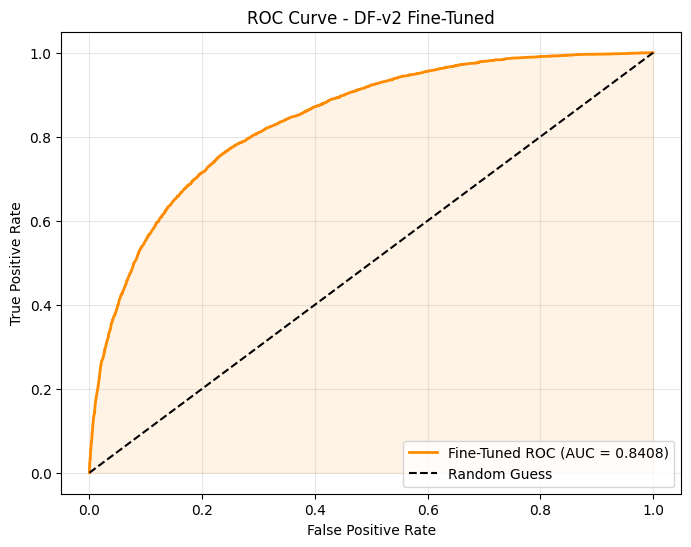

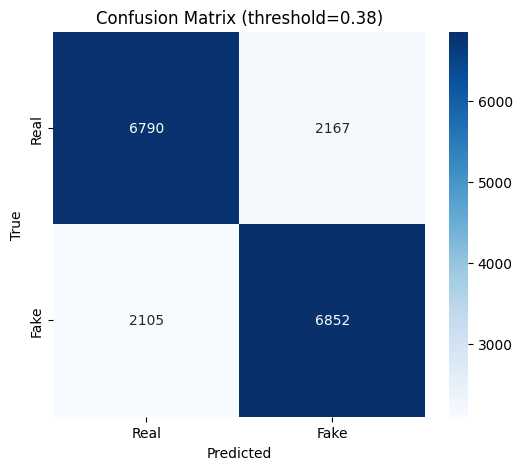

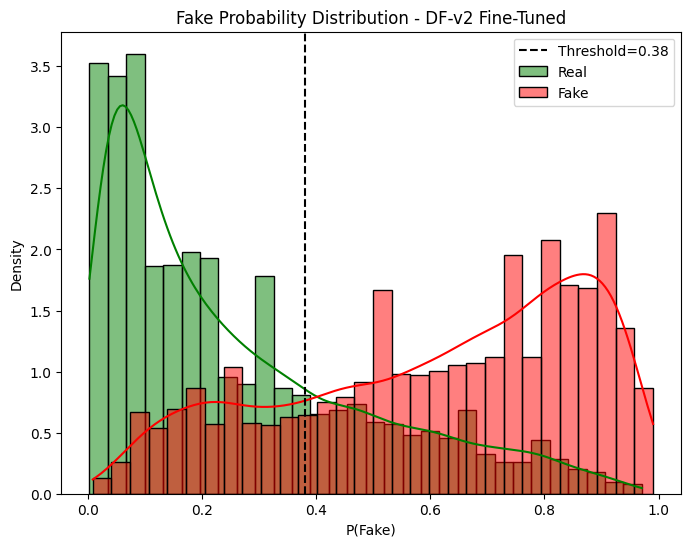

🌌 Generating t-SNE Visualization...
📐 Silhouette Score: 0.0167


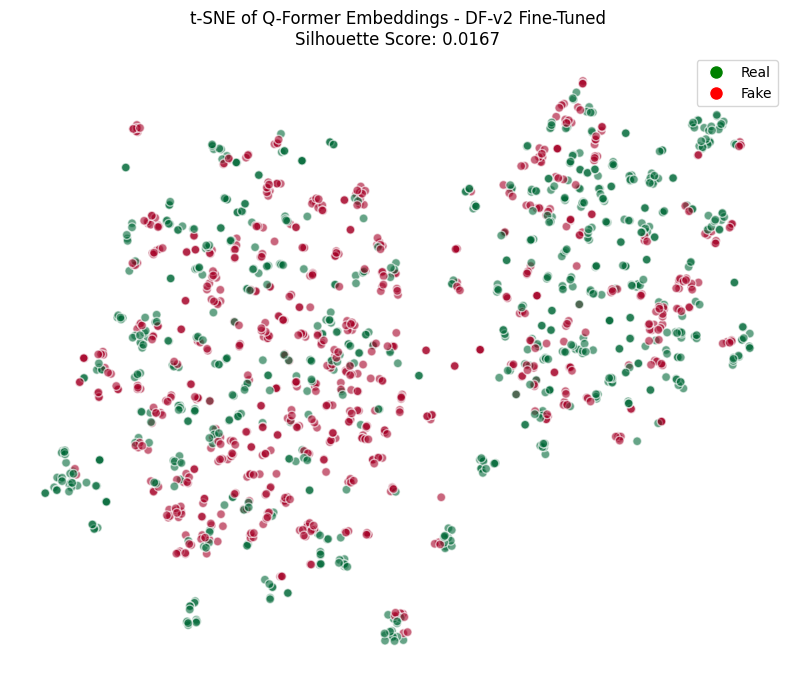


💾 All graphs saved to: /content/drive/MyDrive/Deepfake_Project/Eval_Results_DFv2/Run_2/Graphs


In [ ]:
# --- 8. Advanced Metrics & Visualizations ---

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, silhouette_score, roc_auc_score
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

# ── Paths ─────────────────────────────────────────────────────────────────

base_results_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_DFv2/Run_2'
graph_dir = os.path.join(base_results_dir, 'Graphs')
os.makedirs(graph_dir, exist_ok=True)

# אם Colab קרס - הסר את ה-# מהשורות הבאות וטען מהדרייב:
# all_probs      = np.load(f'{base_results_dir}/finetuned_probs.npy')
# all_labels     = np.load(f'{base_results_dir}/finetuned_labels.npy')
# all_embeddings = np.load(f'{base_results_dir}/finetuned_embeddings.npy')

rng = np.random.RandomState(42)

# ==========================================
# 1. Bootstrap Confidence Intervals (95% CI)
# ==========================================
print("📊 Calculating Bootstrap Confidence Intervals (1000 iterations)...")
bootstrapped_aucs = []

for _ in range(1000):
    indices = rng.randint(0, len(all_probs), len(all_probs))
    if len(np.unique(all_labels[indices])) < 2:
        continue
    bootstrapped_aucs.append(roc_auc_score(all_labels[indices], all_probs[indices]))

sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f"✅ Final ROC-AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")

# ==========================================
# 2. ROC Curve
# ==========================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Fine-Tuned ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DF-v2 Fine-Tuned')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. Confusion Matrix
# ==========================================
binary_preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Probability Distribution
# ==========================================
plt.figure(figsize=(8, 6))
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==0],
             color='green', label='Real', kde=True, stat="density", alpha=0.5, bins=30)
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==1],
             color='red',   label='Fake', kde=True, stat="density", alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)')
plt.ylabel('Density')
plt.title('Fake Probability Distribution - DF-v2 Fine-Tuned')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. t-SNE + Silhouette Score
# ==========================================
print("🌌 Generating t-SNE Visualization...")
sample_size = min(1500, len(all_embeddings))
indices = rng.choice(len(all_embeddings), sample_size, replace=False)
sampled_embeddings = np.array(all_embeddings)[indices]
sampled_labels     = all_labels[indices]

sil_score = silhouette_score(sampled_embeddings, sampled_labels)
print(f"📐 Silhouette Score: {sil_score:.4f}")

embeddings_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(sampled_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=sampled_labels, cmap=plt.cm.RdYlGn_r, alpha=0.6, edgecolors='w', s=40)
custom_lines = [Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10)]
plt.legend(custom_lines, ['Real', 'Fake'])
plt.title(f't-SNE of Q-Former Embeddings - DF-v2 Fine-Tuned\nSilhouette Score: {sil_score:.4f}')
plt.axis('off')
plt.savefig(os.path.join(graph_dir, 'tsne_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 All graphs saved to: {graph_dir}")